# Part 3 — GenAI Bonus Challenge
This notebook explores the free-text complaint field using a simple, reproducible NLP workflow: text cleaning, keyword-based complaint categorisation, and a basic TF-IDF classifier for support-team insight.


In [10]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

plt.style.use('seaborn-v0_8-whitegrid')

DATA_PATH = Path('..') / 'clarity_bookings_dataset.csv'
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('Columns:', list(df.columns))
print('\nComplaint text sample:\n')
print(df['customer_complaint'].dropna().head(10).to_string(index=False))


Shape: (2000, 23)
Columns: ['booking_id', 'booking_date', 'departure_date', 'lead_time_days', 'airline', 'origin', 'destination', 'haul_type', 'cabin_class', 'trip_type', 'fare_basis', 'booking_channel', 'booking_source', 'pax_count', 'base_fare_inr', 'taxes_inr', 'total_fare_inr', 'ancillary_revenue_inr', 'payment_method', 'prior_bookings', 'booking_status', 'customer_complaint', 'satisfaction_score']

Complaint text sample:

             Meal preference not available onboard
                  Schedule change not communicated
             Meal preference not available onboard
Connection time too short, missed connecting fl...
Flight delayed by 3 hours, requesting compensation
                Refund not processed after 30 days
  Duplicate charge on credit card for same booking
        Unable to add extra baggage through portal
                  Schedule change not communicated
Connection time too short, missed connecting fl...


In [2]:
# Inspect missing values and complaint quality

print('Missing complaint values:', df['customer_complaint'].isna().sum())
print('\nComplaint text non-empty share:', df['customer_complaint'].fillna('').astype(str).str.strip().ne('').mean())
print('\nTop booking statuses with complaints:\n', df.groupby('booking_status')['customer_complaint'].apply(lambda s: s.notna().sum()).sort_values(ascending=False).to_string())

# Keep only rows with a complaint for text analysis
complaints_df = df[df['customer_complaint'].notna()].copy()
complaints_df['customer_complaint'] = complaints_df['customer_complaint'].astype(str)
print('\nRows for complaint analysis:', complaints_df.shape[0])


Missing complaint values: 1752

Complaint text non-empty share: 0.124

Top booking statuses with complaints:
 booking_status
Ticketed     91
Cancelled    63
Refunded     61
Confirmed    27
No-Show       6

Rows for complaint analysis: 248


In [3]:
# Clean and normalize complaint text

import re


def clean_text(text: str) -> str:
    text = str(text).lower()
    text = text.replace('refund', 'refund')
    text = text.replace('cancel', 'cancel')
    text = text.replace('delay', 'delay')
    text = re.sub(r"can't", 'cannot', text)
    text = re.sub(r"won't", 'will not', text)
    text = re.sub(r"[^a-z0-9\s]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

complaints_df['clean_text'] = complaints_df['customer_complaint'].apply(clean_text)
print('Example cleaned complaints:\n')
print(complaints_df[['customer_complaint', 'clean_text']].head(5).to_string(index=False))


Example cleaned complaints:

                                 customer_complaint                                         clean_text
              Meal preference not available onboard              meal preference not available onboard
                   Schedule change not communicated                   schedule change not communicated
              Meal preference not available onboard              meal preference not available onboard
Connection time too short, missed connecting flight connection time too short missed connecting flight
 Flight delayed by 3 hours, requesting compensation  flight delayed by 3 hours requesting compensation


In [4]:
# Create baseline complaint categories with keyword rules

keyword_rules = {
    'Refund Issues': [r'\brefund\b', r'\bchargeback\b', r'\breturn\b'],
    'Schedule Change': [r'\bdelay\b', r'\breschedul\b', r'\bchange flight\b', r'\btime change\b'],
    'Baggage': [r'\bbaggage\b', r'\blost luggage\b', r'\bdamaged bag\b'],
    'Pricing Error': [r'\bprice\b', r'\bfare\b', r'\bcharged\b', r'\bextra fee\b'],
    'Ticketing Issues': [r'\bticket\b', r'\bbooking error\b', r'\bconfirmation\b', r'\breservation\b'],
    'Customer Service': [r'\bagent\b', r'\bcustomer service\b', r'\bcall center\b'],
}


def rule_label(text: str) -> str:
    text = text.lower()
    for label, patterns in keyword_rules.items():
        if any(re.search(p, text) for p in patterns):
            return label
    return 'Other'

complaints_df['rule_category'] = complaints_df['clean_text'].apply(rule_label)

print('Rule-based category distribution:\n')
print(complaints_df['rule_category'].value_counts().to_string())


Rule-based category distribution:

rule_category
Other               129
Ticketing Issues     54
Baggage              31
Refund Issues        20
Pricing Error        14


In [12]:
# Build a TF-IDF + Logistic Regression classifier

X = complaints_df['clean_text']
y = complaints_df['rule_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

model = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2),
    LogisticRegression(max_iter=2000, class_weight='balanced', solver='lbfgs')
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, pred), 3))
print('F1-score:', round(f1_score(y_test, pred, average='weighted'), 3))
print('\nClassification report:\n')
print(classification_report(y_test, pred, zero_division=0))



Accuracy: 1.0
F1-score: 1.0

Classification report:

                  precision    recall  f1-score   support

         Baggage       1.00      1.00      1.00         6
           Other       1.00      1.00      1.00        26
   Pricing Error       1.00      1.00      1.00         3
   Refund Issues       1.00      1.00      1.00         4
Ticketing Issues       1.00      1.00      1.00        11

        accuracy                           1.00        50
       macro avg       1.00      1.00      1.00        50
    weighted avg       1.00      1.00      1.00        50



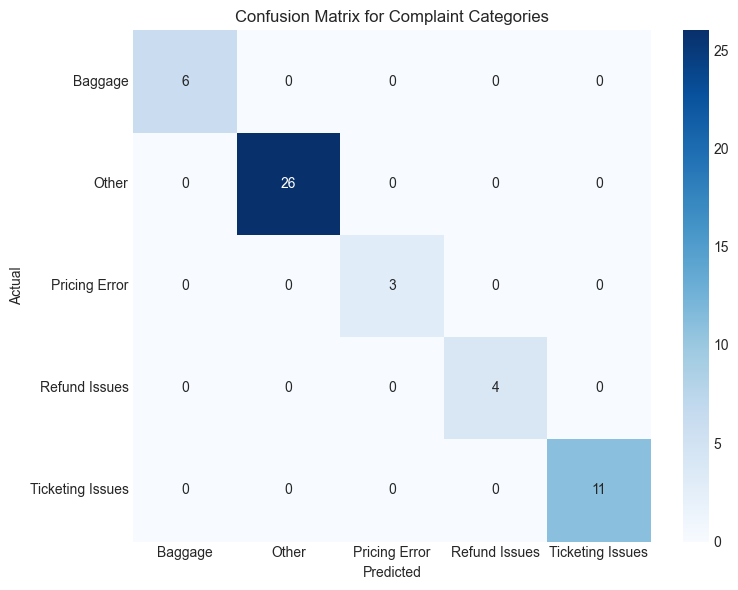

In [13]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.named_steps['logisticregression'].classes_, yticklabels=model.named_steps['logisticregression'].classes_)
plt.title('Confusion Matrix for Complaint Categories')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

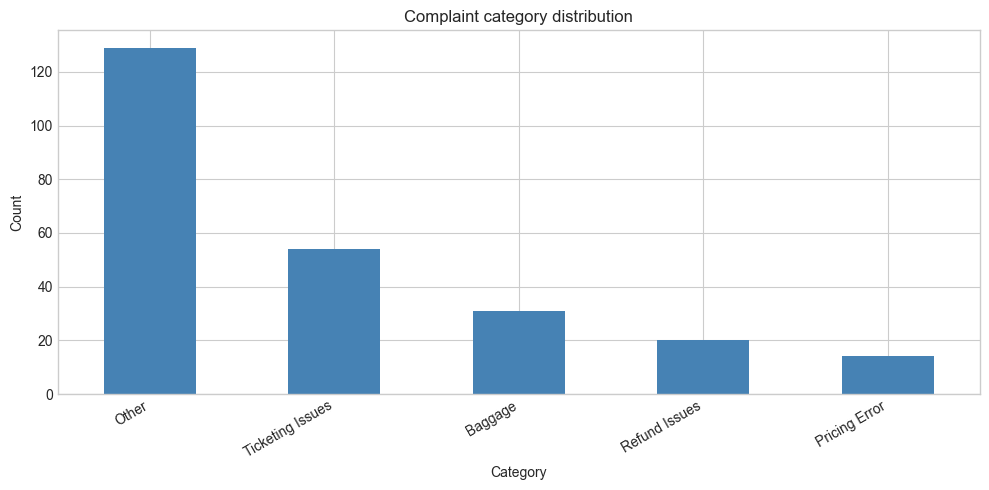

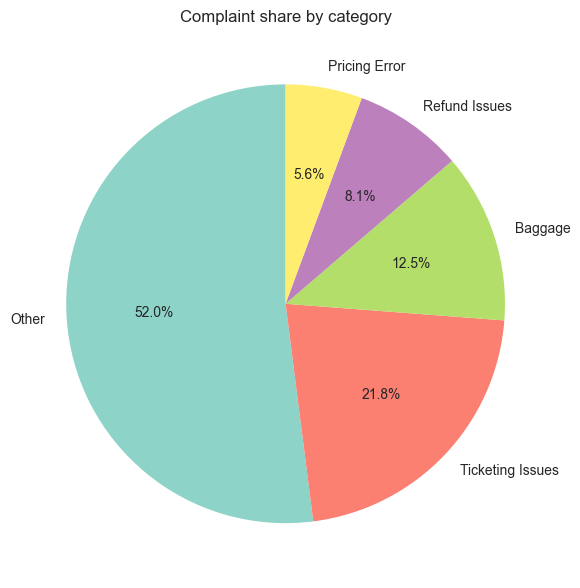

In [7]:
# Visualise category distribution

plt.figure(figsize=(10, 5))
ax = complaints_df['rule_category'].value_counts().plot(kind='bar', color='steelblue')
ax.set_title('Complaint category distribution')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
complaints_df['rule_category'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Set3')
plt.title('Complaint share by category')
plt.ylabel('')
plt.tight_layout()
plt.show()


Complaint category by booking status:

   rule_category booking_status  count
           Other      Cancelled     24
Ticketing Issues      Cancelled     16
         Baggage      Cancelled     12
   Refund Issues      Cancelled      6
   Pricing Error      Cancelled      5
           Other      Confirmed     14
Ticketing Issues      Confirmed      7
   Refund Issues      Confirmed      4
         Baggage      Confirmed      2
           Other        No-Show      3
   Pricing Error        No-Show      2
         Baggage        No-Show      1
           Other       Refunded     39
Ticketing Issues       Refunded     11
         Baggage       Refunded      5
   Pricing Error       Refunded      3
   Refund Issues       Refunded      3
           Other       Ticketed     49
Ticketing Issues       Ticketed     20
         Baggage       Ticketed     11
   Refund Issues       Ticketed      7
   Pricing Error       Ticketed      4


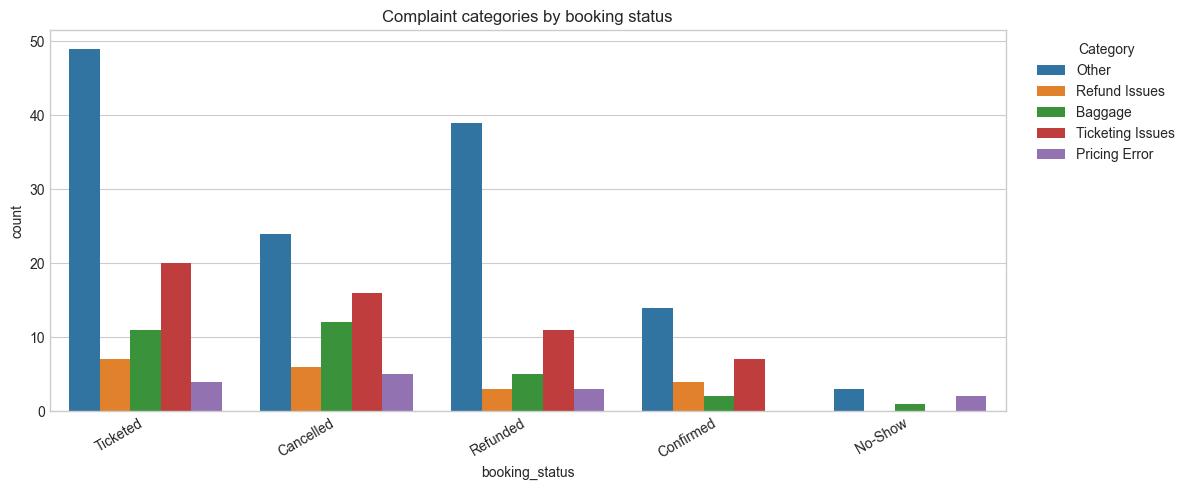

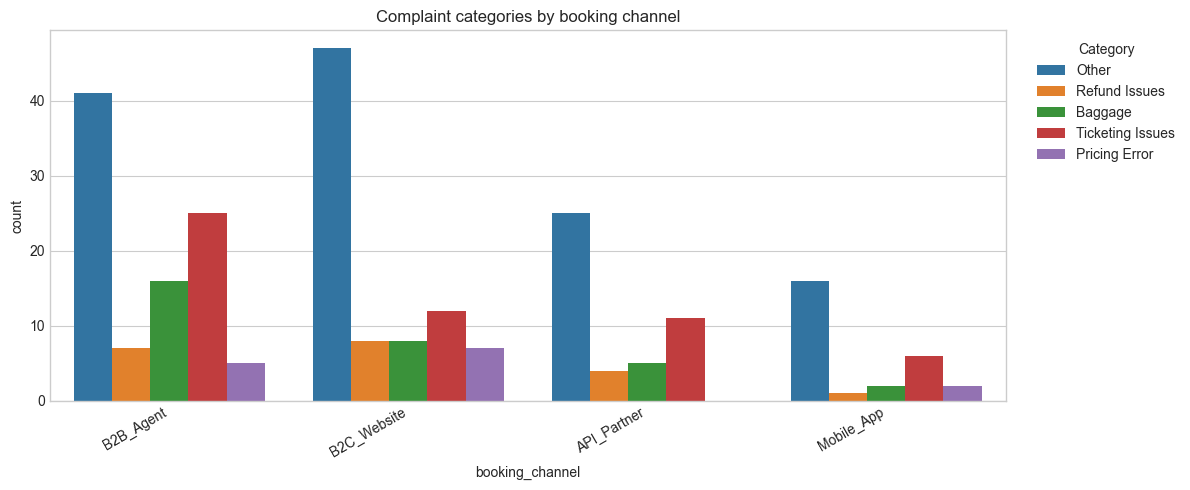

In [8]:
# Correlate complaint categories with airline, booking channel, and status

summary = complaints_df.groupby(['rule_category', 'booking_status']).size().reset_index(name='count')
print('Complaint category by booking status:\n')
print(summary.sort_values(['booking_status', 'count'], ascending=[True, False]).to_string(index=False))

plt.figure(figsize=(12, 5))
sns.countplot(data=complaints_df, x='booking_status', hue='rule_category', order=complaints_df['booking_status'].value_counts().index)
plt.title('Complaint categories by booking status')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.countplot(data=complaints_df, x='booking_channel', hue='rule_category', order=complaints_df['booking_channel'].value_counts().index)
plt.title('Complaint categories by booking channel')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
